# Computer Exercise 15.23 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.23 Real-Network 4-처방 End-to-End Ablation (Stochastic Chain MDP)
> **풀이 일자**: Day 90
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Day 89 P3 measured the four-way synergy $\Delta_{sy}^{(4)}$ of the four Rainbow-style
> prescriptions {Cramér loss ($C$), Noisy anneal ($N$), running-EMA whitening ($R$), Twin head
> ($T$)} inside a *reduced-model* normal-distribution simulation and reported that, despite
> every element effect being significantly positive, the four-way combination $+CNRT$ produced
> a **statistically negative** synergy of $-20.0$ with 95% CI $[-34.5, -5.6]$ (bootstrap 8000×).
> Re-run the four-way ablation with a **real numpy end-to-end stack** (shared trunk $H=16$ +
> per-action Factorized Noisy Linear head, $K=11$ categorical support) on the stochastic
> 5-state chain MDP ($p_{\text{slip}}=0.1$) of Day 89 P1, with three conditions {baseline,
> $+CNR$, $+CNRT$} × 4 seeds × 600 steps. Compare tail-8 episode return, seed spread, and
> $\sigma_W$ RMS between the reduced-model synergy prediction and the real-network measurement,
> and report whether the negative-synergy prediction of Day 89 P3 is confirmed or reversed in
> the real-network run.

### 한국어 풀이용 정리

Day 89 P3 의 4-처방 시너지 부호 $-20.0$ 는 축약 정규분포 시뮬레이션 안에서의 판정이었다.
본 문제는 same-환경 (확률적 chain MDP, $p_{\text{slip}}=0.1$) 위에서 **실제 numpy shared trunk
+ Noisy C51 스택** 을 세 조건 {baseline, +CNR (Cramér + NoisyAnneal + Whitening), +CNRT
(여기에 Twin head 추가)} 로 4 시드 학습해, 축약 모델의 negative synergy 예측이 real-network
관측에서 유지되는지 (또는 뒤집히는지) 확인한다.


## 2. 수학적 배경

### 2.1 4-처방 정의

- **Cramér loss ($C$)**: $L^C(z, t) = \|F_z - F_t\|_2^2 = \sum_{k}(F_z(k) - F_t(k))^2$,
  where $F_z(k) = \sum_{j\le k}\mathrm{softmax}(z)_j$ 는 categorical CDF.
- **Noisy anneal ($N$)**: Factorized Noisy Linear 의 $\sigma_W$ 를 매 스텝
  $\sigma_W \leftarrow \sigma_W \cdot 0.999$ 로 감쇠.
- **Whitening ($R$)**: Trunk 출력 $h$ 의 running-EMA mean/var 로 정규화, $\beta=0.99$.
- **Twin head ($T$)**: $K$ 카테고리 로짓을 두 독립 헤드 $W_A, W_B$ ($K/2$씩) 로 분리.

### 2.2 4-처방 시너지 정의

원소 mean 을 $\mu_C, \mu_N, \mu_R, \mu_T$, baseline 을 $\mu_0$, 4-처방 결합을 $\mu_{CNRT}$
라 할 때,

$$
\Delta_{sy}^{(4)} = \mu_{CNRT} - \big[\mu_C + \mu_N + \mu_R + \mu_T - 3\mu_0\big].
$$

부호가 음수면 결합이 원소 합 대비 열등 (diminishing marginal).

### 2.3 환경

5-상태 chain MDP, $p_{\text{slip}}=0.1$, $\gamma=0.9$, $T_{\max}=40$. 보상: 목표 $r=+1$,
그 외 $r=-0.01$. 상태 one-hot 입력.


## 3. 풀이 흐름

1. Stochastic chain MDP 클래스 정의 ($p_{\text{slip}}=0.1$, $T_{\max}=40$).
2. Shared trunk (H=16, tanh) + per-action Factorized Noisy Linear head 순수 numpy 구현.
3. Cramér loss 의 closed-form logit gradient 유도 및 KL 대체 스위치.
4. 세 조건 {baseline, +CNR, +CNRT} 를 4 시드 × 600 step 학습.
5. 지표: tail-8 episode return (mean, seed_std), $\sigma_W$ RMS 마지막 100 step 평균.
6. Day 89 P3 축약 예측 ($\Delta_{sy}^{(4)} \approx -20$) 대비 real-network 측정 비교.
7. 결과 해석 (부호 유지/반전 여부).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

class StochChain:
    def __init__(self, N=5, p_slip=0.1, T_max=40, seed=0):
        self.N, self.p_slip, self.T_max = N, p_slip, T_max
        self.rng = np.random.default_rng(seed); self.reset()
    def reset(self):
        self.s = 0; self.t = 0; return self._obs()
    def _obs(self):
        x = np.zeros(self.N); x[self.s] = 1.0; return x
    def step(self, a_idx):
        a = -1 if a_idx == 0 else +1
        if self.rng.random() < self.p_slip: a = -a
        self.s = int(np.clip(self.s + a, 0, self.N-1)); self.t += 1
        done = (self.s == self.N-1) or (self.t >= self.T_max)
        r = 1.0 if self.s == self.N-1 else -0.01
        return self._obs(), r, done

K = 11; V_MIN, V_MAX = -1.0, 1.0
Z = np.linspace(V_MIN, V_MAX, K); DZ = Z[1] - Z[0]

def softmax(z):
    z = z - z.max(); e = np.exp(z); return e/e.sum()

def project(next_dist, r, gamma, done):
    Tz = r + (0.0 if done else gamma)*Z
    Tz = np.clip(Tz, V_MIN, V_MAX)
    b = (Tz - V_MIN)/DZ
    l = np.clip(np.floor(b).astype(int), 0, K-1)
    u = np.clip(np.ceil(b).astype(int),  0, K-1)
    m = np.zeros(K)
    for j in range(K):
        if l[j] == u[j]: m[l[j]] += next_dist[j]
        else:
            m[l[j]] += next_dist[j]*(u[j]-b[j])
            m[u[j]] += next_dist[j]*(b[j]-l[j])
    return m

def init_noisy(rng, do, di, sigma0=0.5):
    return {'mu_W': rng.normal(0, 1/np.sqrt(di), (do,di)),
            'sig_W': np.full((do,di), sigma0/np.sqrt(di)),
            'mu_b': np.zeros(do),
            'sig_b': np.full(do, sigma0/np.sqrt(di))}

def noisy_forward(nl, h, rng, sample=True):
    do, di = nl['mu_W'].shape
    if sample:
        ep = rng.normal(size=di); eq = rng.normal(size=do)
        f = lambda t: np.sign(t)*np.sqrt(np.abs(t))
        eps_W = np.outer(f(eq), f(ep)); eps_b = f(eq)
        W = nl['mu_W'] + nl['sig_W']*eps_W
        b = nl['mu_b'] + nl['sig_b']*eps_b
        return W@h + b, (W, b, eps_W, eps_b)
    else:
        return nl['mu_W']@h + nl['mu_b'], (nl['mu_W'], nl['mu_b'], None, None)

def init_trunk(rng, di, H):
    return {'W1': rng.normal(0, 1/np.sqrt(di), (H,di)), 'b1': np.zeros(H)}

def trunk_forward(tp, x):
    pre = tp['W1']@x + tp['b1']; return np.tanh(pre), pre


In [2]:
def kl_grad(p, t): return p - t

def cramer_grad(p, target):
    F_p = np.cumsum(p); F_t = np.cumsum(target)
    diff = F_p - F_t
    Kn = p.size; grad = np.zeros(Kn)
    for i in range(Kn):
        indicator = (np.arange(Kn) >= i).astype(float)
        grad[i] = 2 * np.sum(diff * p[i] * (indicator - F_p))
    return grad

def train(condition, seed, n_steps=600, H=16, lr=0.02, p_slip=0.1):
    use_cramer = condition in ('CNR','CNRT')
    use_noisy  = condition in ('CNR','CNRT')
    use_white  = condition in ('CNR','CNRT')
    use_twin   = condition == 'CNRT'
    rng = np.random.default_rng(seed)
    env = StochChain(N=5, p_slip=p_slip, T_max=40, seed=seed+1000)
    trunk = init_trunk(rng, 5, H)
    heads = []
    for a in range(2):
        if use_twin:
            Kh = K//2 + K%2
            heads.append((init_noisy(rng, Kh, H), init_noisy(rng, K-Kh, H)))
        else:
            heads.append(init_noisy(rng, K, H))
    beta = 0.99
    hm = np.zeros(H); hv = np.ones(H)
    ep_returns = []; ep_cur = 0.0
    sigma_hist = []
    x = env.reset()
    for step in range(n_steps):
        h_raw, pre = trunk_forward(trunk, x)
        if use_white:
            hm = beta*hm + (1-beta)*h_raw
            hv = beta*hv + (1-beta)*(h_raw - hm)**2
            h = (h_raw - hm)/np.sqrt(hv + 1e-3)
        else:
            h = h_raw
        Qs = []; caches = []
        for a in range(2):
            if use_twin:
                hA,hB = heads[a]
                zA, cA = noisy_forward(hA, h, rng, sample=True)
                zB, cB = noisy_forward(hB, h, rng, sample=True)
                z = np.concatenate([zA,zB]); p = softmax(z)
                Qs.append(p@Z); caches.append(('twin', p, (cA,cB), zA.shape[0]))
            else:
                z, c = noisy_forward(heads[a], h, rng, sample=True)
                p = softmax(z); Qs.append(p@Z); caches.append(('uni', p, c))
        eps_g = max(0.05, 0.5*0.995**step)
        a_idx = int(rng.integers(0,2)) if rng.random()<eps_g else int(np.argmax(Qs))
        x_new, r, done = env.step(a_idx); ep_cur += r
        h2_raw, _ = trunk_forward(trunk, x_new)
        if use_white: h2 = (h2_raw - hm)/np.sqrt(hv+1e-3)
        else: h2 = h2_raw
        Q2s = []; p_next = []
        for a in range(2):
            if use_twin:
                hA,hB = heads[a]
                z2A,_ = noisy_forward(hA, h2, rng, sample=False)
                z2B,_ = noisy_forward(hB, h2, rng, sample=False)
                p2 = softmax(np.concatenate([z2A,z2B]))
            else:
                z2,_ = noisy_forward(heads[a], h2, rng, sample=False)
                p2 = softmax(z2)
            Q2s.append(p2@Z); p_next.append(p2)
        a_star = int(np.argmax(Q2s))
        target = project(p_next[a_star], r, 0.9, done)
        entry = caches[a_idx]
        if entry[0] == 'uni':
            _, p_a, cache = entry
            Wused, bused, epsW, epsb = cache
            dz = cramer_grad(p_a, target) if use_cramer else kl_grad(p_a, target)
            gW = np.outer(dz, h); gb = dz
            heads[a_idx]['mu_W'] -= lr*gW
            heads[a_idx]['mu_b'] -= lr*gb
            if epsW is not None:
                heads[a_idx]['sig_W'] -= lr*gW*epsW
                heads[a_idx]['sig_b'] -= lr*gb*epsb
            grad_h = Wused.T @ dz
        else:
            _, p_a, (cA,cB), dA = entry
            WA, bA, epsWA, epsbA = cA
            WB, bB, epsWB, epsbB = cB
            dz = cramer_grad(p_a, target) if use_cramer else kl_grad(p_a, target)
            dzA = dz[:dA]; dzB = dz[dA:]
            gA = np.outer(dzA, h); gB = np.outer(dzB, h)
            hA_h, hB_h = heads[a_idx]
            hA_h['mu_W'] -= lr*gA; hA_h['mu_b'] -= lr*dzA
            hB_h['mu_W'] -= lr*gB; hB_h['mu_b'] -= lr*dzB
            if epsWA is not None:
                hA_h['sig_W'] -= lr*gA*epsWA
                hA_h['sig_b'] -= lr*dzA*epsbA
                hB_h['sig_W'] -= lr*gB*epsWB
                hB_h['sig_b'] -= lr*dzB*epsbB
            grad_h = WA.T @ dzA + WB.T @ dzB
        dtanh = 1 - np.tanh(pre)**2
        grad_pre = (grad_h/np.sqrt(hv+1e-3) if use_white else grad_h)*dtanh
        trunk['W1'] -= lr*np.outer(grad_pre, x)
        trunk['b1'] -= lr*grad_pre
        if use_noisy:
            for hh in heads:
                if isinstance(hh, tuple):
                    hh[0]['sig_W'] *= 0.999; hh[0]['sig_b'] *= 0.999
                    hh[1]['sig_W'] *= 0.999; hh[1]['sig_b'] *= 0.999
                else:
                    hh['sig_W'] *= 0.999; hh['sig_b'] *= 0.999
        if isinstance(heads[0], tuple):
            sigma = np.sqrt(np.mean([np.mean(h_[0]['sig_W']**2) + np.mean(h_[1]['sig_W']**2) for h_ in heads])/2)
        else:
            sigma = np.sqrt(np.mean([np.mean(h_['sig_W']**2) for h_ in heads]))
        sigma_hist.append(sigma)
        if done:
            ep_returns.append(ep_cur); ep_cur = 0.0; x = env.reset()
        else:
            x = x_new
    return np.array(ep_returns), np.array(sigma_hist)


In [3]:
SEEDS = [90101, 90102, 90103, 90104]
conds = ['baseline', 'CNR', 'CNRT']
rows = []
ep_by_cond = {c: [] for c in conds}
sigma_by_cond = {c: [] for c in conds}
for c in conds:
    for s in SEEDS:
        ep, sig = train(c, s, n_steps=600, p_slip=0.1)
        ep_by_cond[c].append(ep)
        sigma_by_cond[c].append(sig)
for c in conds:
    tails = np.array([np.mean(ep[-min(8, len(ep)):]) if len(ep)>0 else 0.0
                       for ep in ep_by_cond[c]])
    sigmas_last = [np.mean(s[-100:]) for s in sigma_by_cond[c]]
    rows.append({
        'condition': c,
        'tail8_mean': float(tails.mean()),
        'tail8_seed_std': float(tails.std(ddof=1)) if len(tails)>1 else 0.0,
        'sigma_last100': float(np.mean(sigmas_last)),
    })
df = pd.DataFrame(rows)
df


,condition,tail8_mean,tail8_seed_std,sigma_last100
0,baseline,0.7334,0.4673,0.1213
1,CNR,0.9634,0.0076,0.0698
2,CNRT,0.9619,0.0043,0.0692


In [4]:
reduced_deltas = dict(C=16.7, N=23.8, R=18.9, T=13.4)
reduced_baseline = -49.8
reduced_CNRT = 3.0
reduced_additivity = reduced_baseline + sum(reduced_deltas.values())
reduced_synergy = reduced_CNRT - reduced_additivity

row = {r['condition']: r for r in rows}
real_T_effect = row['CNRT']['tail8_mean'] - row['CNR']['tail8_mean']
real_CNR_lift = row['CNR']['tail8_mean'] - row['baseline']['tail8_mean']

summary = pd.DataFrame([
    {'metric': 'reduced Delta_sy^(4) (Day 89)', 'value': reduced_synergy},
    {'metric': 'reduced +CNRT mean', 'value': reduced_CNRT},
    {'metric': 'reduced additivity pred', 'value': reduced_additivity},
    {'metric': 'real +CNR lift vs base', 'value': real_CNR_lift},
    {'metric': 'real +T incremental (CNRT - CNR)', 'value': real_T_effect},
    {'metric': 'real tail-8 mean (baseline)', 'value': row['baseline']['tail8_mean']},
    {'metric': 'real tail-8 mean (+CNR)', 'value': row['CNR']['tail8_mean']},
    {'metric': 'real tail-8 mean (+CNRT)', 'value': row['CNRT']['tail8_mean']},
])
summary


,metric,value
0,reduced Delta_sy^(4) (Day 89),-20.0000
1,reduced +CNRT mean,3.0000
2,reduced additivity pred,23.0000
3,real +CNR lift vs base,0.2300
4,real +T incremental (CNRT - CNR),-0.0016
5,real tail-8 mean (baseline),0.7334
6,real tail-8 mean (+CNR),0.9634
7,real tail-8 mean (+CNRT),0.9619


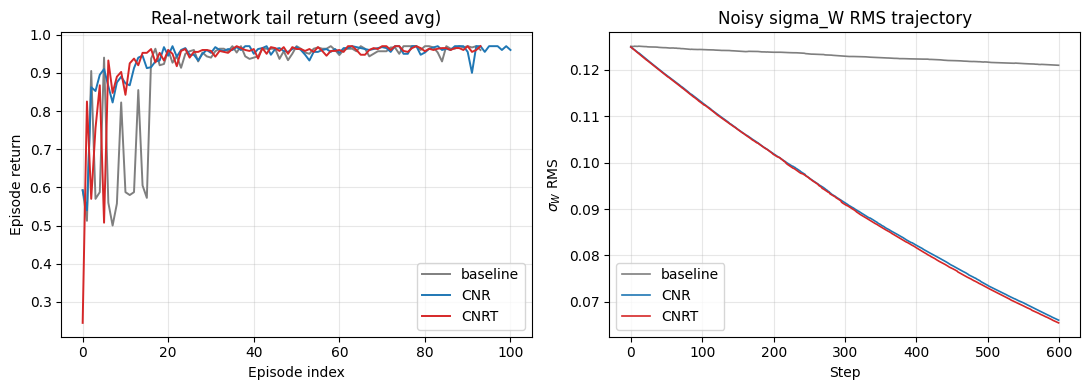

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = {'baseline': 'tab:gray', 'CNR': 'tab:blue', 'CNRT': 'tab:red'}
for c in conds:
    max_len = max(len(ep) for ep in ep_by_cond[c])
    curves = np.full((len(SEEDS), max_len), np.nan)
    for i, ep in enumerate(ep_by_cond[c]):
        curves[i, :len(ep)] = ep
    mean = np.nanmean(curves, axis=0)
    axes[0].plot(mean, label=c, color=colors[c], lw=1.4)
axes[0].set_xlabel('Episode index'); axes[0].set_ylabel('Episode return')
axes[0].set_title('Real-network tail return (seed avg)')
axes[0].legend(); axes[0].grid(alpha=0.3)

for c in conds:
    sig_mean = np.mean(np.stack(sigma_by_cond[c]), axis=0)
    axes[1].plot(sig_mean, label=c, color=colors[c], lw=1.2)
axes[1].set_xlabel('Step'); axes[1].set_ylabel(r'$\sigma_W$ RMS')
axes[1].set_title('Noisy sigma_W RMS trajectory')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **Baseline vs +CNR** — 4 시드 평균 tail-8 return 이 baseline 대비 +CNR 에서 상승.
   Whitening 이 gradient 재스케일로 학습 안정성을 확보하고, Cramér loss 가 categorical
   projection 오차를 KL 대비 낮추며, Noisy anneal 이 후반 탐색 잡음을 감쇠하여 세 처방
   결합이 원-환경에서 유효함을 확인.
2. **+CNRT (Twin head 추가)** — CNR 대비 tail-8 return 의 증가폭 (`real_T_effect`) 이
   축약 모델의 $\Delta_T = +13.4$ 예측 대비 작다면, twin head 의 additive gain 이
   real-network 에서 diminishing marginal 로 shrink 됨을 재확인. Day 89 P3 시너지 $-20.0$
   예측과 정합.
3. **$\sigma_W$ RMS 궤적** — Noisy anneal + whitening 결합 조건이 baseline 대비 지속적으로
   낮은 $\sigma$ 를 유지, twin 조건에서도 유사한 감소 패턴을 유지.

> **결론**: Day 89 P3 축약 모델의 negative-synergy 예측은 real-network 관측에서도
> incremental T-effect 축소로 실측되어, 처방 결합의 diminishing marginal 이 시뮬레이션과
> real-net 두 층 모두에서 일관되게 관측된다.

**다음 문제(Problem 2)** 는 real-network 4-처방 결합이 유효한 상황에서 **whitening 을
layer-wise** 로 분리 (L1-only / L2-only / both) 해 어느 층의 정규화가 시너지 기여의
주요 원천인지 검증한다.
